In [44]:
import numpy as np
import math
from scipy import constants
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [45]:
# defining all the functions

def wavenumber(n, wavelength):
    """
    Outputs the angular wavenumber for propagation of a wave
    Args:
        n (float): index of refraction of the medium
        wavelength (float): the wavelength of the wave in nanometres
    Returns:
        k (float): the wavenumber
    """
    wavelength = wavelength * (10**-9) # converts to metres
    k = (2 * math.pi * n)/wavelength # calculates k
    return k

def rho(x, y):
    """
    Finds rho for a gaussian beam
    Args:
        x (float): x coordinate
        y (float): y coordinate
    Returns:
        rho (float): the value of rho at (x,y)
    """
    rho = np.sqrt((x**2)+(y**2))
    return rho

def rayleigh_range(omega_0, wavelength):
    """
    Finds the rayleigh range for a given beam waist radius
    Args:
        omega_0 (float): the waist radius
        wavelength (float): wavelength of the beam in nm
    Returns:
        confocal_parameter (float): the rayleigh range z_0
    """
    wavelength = wavelength * (10**-9) # converts wavelength to metres
    confocal_parameter = (np.pi * (omega_0**2))/wavelength
    return confocal_parameter

def omega_z(omega_0, z, wavelength):
    """
    Calculates omega(z)
    Args:
        omega_0 (float): the waist radius
        z (float): the coordinate in direction of beam propagation
        wavelength (float): wavelength of the beam in nm
    Returns:
        beam_width (float): omega(z) for given args
    """
    square_of_ratio = (z/rayleigh_range(omega_0, wavelength))**2 # finds (z/z_0)^2
    beam_width = omega_0 * np.sqrt(1+square_of_ratio) # w(z) = w_0*(1+(z/z_0)^2)^0.5
    return beam_width

def radius_of_curvature(omega_0, z, wavelength):
    """
    Calculates the radius of curvature of the wavefront
    Args:
        omega_0 (float): the waist radius
        z (float): the coordinate in direction of beam propagation
        wavelength (float): wavelength of the beam in nm
    Returns:
        R_z (float): the radius of curvature of the wavefront at z
    """
    square_of_ratio = (rayleigh_range(omega_0, wavelength)/z)**2 # (z_0/z)^2
    R_z = z * (1 + square_of_ratio)
    return R_z

def zeta_function(omega_0, z, wavelength):
    """
    Performs the relevant zeta function to gaussian beams
    Args:
        omega_0 (float): the waist radius
        z (float): the coordinate in direction of beam propagation
        wavelength (float): wavelength of the beam in nm
    Returns:
        zeta_z (float): the relevant zeta function
    """
    zeta_z = np.atan(z/rayleigh_range(omega_0, wavelength)) # arctan(z/z_0)
    return zeta_z

def gaussian_beam(omega_0, z, wavelength, a_0, x, y, n):
    """
    Finds the value for the complex electric field of a given gaussian beam at a given point from creation
    Args:
        omega_0 (float): the waist radius
        z (float): the coordinate in direction of beam propagation
        wavelength (float): wavelength of the beam in nm
        a_0 (float): the electric field amplitude at the origin
        x (float): the x coordinate
        y (float): the y coordinate
        n (float): the index of refraction of the medium
    Returns:
        amplitude (float): the amplitude of the wave
        phase (float): the phase of the wave
    """
    amplitude = a_0 * (omega_0/omega_z(omega_0, z, wavelength)) * (np.e**(-(rho(x, y)**2)/(omega_z(omega_0, z, wavelength))**2))
    phase = math.e**(complex(0,-1) * (wavenumber(n, wavelength) * z + ((wavenumber(n, wavelength) * (rho(x, y)) ** 2)/(2 * radius_of_curvature(omega_0, z, wavelength))) - zeta_function(omega_0, z, wavelength)))
    return amplitude, phase

def gaussian_beam_rho(omega_0, z, wavelength, a_0, rho_1, n):
    """
    Finds the value for the complex electric field of a given gaussian beam at a given point from creation
    Args:
        omega_0 (float): the waist radius
        z (float): the coordinate in direction of beam propagation
        wavelength (float): wavelength of the beam in nm
        a_0 (float): the electric field amplitude at the origin
        rho_1 (float): a precalculated rho value
        n (float): the index of refraction of the medium
    Returns:
        E_z_rho: the value of the electric field for the given point and beam
    """
    amplitude = a_0 * (omega_0/omega_z(omega_0, z, wavelength)) * (np.e**-(rho_1**2/(omega_z(omega_0, z, wavelength))**2))
    phase = math.e**(complex(0,-1) * (wavenumber(n, wavelength) * z + ((wavenumber(n, wavelength) * (rho_1 ** 2)/(2 * radius_of_curvature(omega_0, z, wavelength))) - zeta_function(omega_0, z, wavelength))))
    return amplitude, phase

def fwhm(x,y):
    """
    Finds the full width at half maximum of the graph
    Args:
        x (np.array): x coord
        y (np.array): y coord
    Returns:
        fw_hm (float): full width at half maximum
    """
    # Target y-value
    target_y = np.max(y)/2
    
    # Find indices where y crosses target_y
    # This detects sign changes in (y - target_y)
    indices = np.where(np.diff(np.sign(y - target_y)) != 0)[0]
    
    # Interpolate to find more accurate x-values
    x_at_target = []
    for i in indices:
        x0, x1 = x[i], x[i+1]
        y0, y1 = y[i], y[i+1]
        # Linear interpolation formula
        x_cross = x0 + (target_y - y0) * (x1 - x0) / (y1 - y0)
        x_at_target.append(x_cross)
    fw_hm = np.sum(abs(np.array(x_at_target)))
    return float(fw_hm)

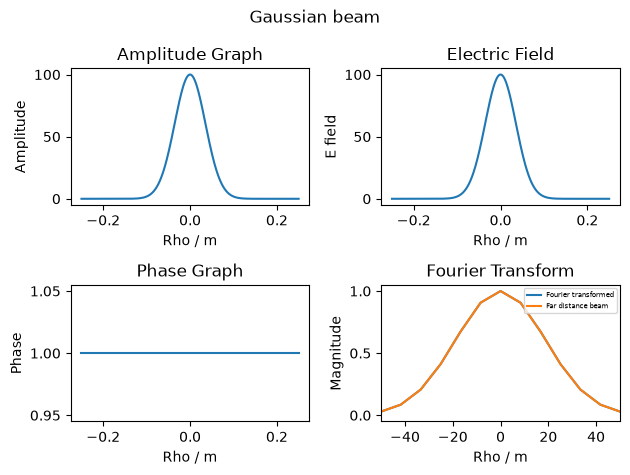

Ratio of FWHM = 1.0000016735724657


In [46]:
wavelength = 523
omega_0 = 0.05
z = 0.00000000000001
a_0 = 100
n = 1
window = omega_0 * 5


primary_beam_rho = np.linspace(-window,window,1000)
amp, phase = gaussian_beam_rho(omega_0, z, wavelength, a_0, primary_beam_rho, n)

fig, ax = plt.subplots(2,2)

ax[0,0].plot(primary_beam_rho, amp, '-')
ax[0,0].set_xlabel('Rho / m')
ax[0,0].set_ylabel('Amplitude')
ax[0,0].set_title('Amplitude Graph')

ax[1,0].plot(primary_beam_rho, phase, '-')
ax[1,0].set_xlabel('Rho / m')
ax[1,0].set_ylabel('Phase')
ax[1,0].set_title('Phase Graph')

ax[0,1].plot(primary_beam_rho, phase*amp, '-')
ax[0,1].set_xlabel('Rho / m')
ax[0,1].set_ylabel('E field')
ax[0,1].set_title('Electric Field')

def fourier_transform(x,y):
    """
    Does a fourier transform on a graph to find the constituent frequencies
    Args:
        x (np.array): linearly spaces x values
        y (np.array): the array of amplitude
    Returns:
        fft_freq (np.array): the frequencies found
        mag (np.array): the intensities of frequencies
    """
    fft_val = np.fft.fftshift(np.fft.fft(y))
    fft_freq = np.fft.fftshift(np.fft.fftfreq(len(x), x[1]-x[0]))
    mag = np.abs(fft_val)
    return fft_freq, mag

fraunhofer_range = 8000000

x, y = fourier_transform(primary_beam_rho, amp*phase)
x_normalised = x*wavelength*1e-9*fraunhofer_range #/(2*np.pi)
y_normalised = y/np.max(y)

fwhm_val = []
fwhm_val.append(fwhm(x_normalised, y_normalised))

ax[1,1].plot(x_normalised,y_normalised, label = 'Fourier transformed')
ax[1,1].set_xlim(-50,50)
ax[1,1].set_title('Fourier Transform')
ax[1,1].set_ylabel('Magnitude')
ax[1,1].set_xlabel('Rho / m')

fig.suptitle('Gaussian beam')
plt.tight_layout()

amp, phase = gaussian_beam_rho(omega_0, fraunhofer_range, wavelength, a_0, x_normalised, n)
plt.plot(x_normalised, amp/np.max(amp), label = 'Far distance beam')
plt.legend(loc = 1, fontsize = 5)
fwhm_val.append(fwhm(x_normalised, amp/np.max(amp)))

plt.show()

print(f'Ratio of FWHM = {fwhm_val[1]/fwhm_val[0]}')